 Credit Risk Analytics

 Module 1 - Exploratory Data Analysis (EDA)

Objective

The objective of this phase is to understand the Lending Club loan dataset and identify the key factors that may contribute towards borrower default. Before building any machine learning models, it is important to first understand the structure of the data and asses its quality.

This analysis will focus on data ingestion, dataset overview, missing value assesment, feature understanding and identifying initial observations that can help in the later stages of model development.

Dataset

Dataset Used: Lending Club Accepted Loans Dataset (2007 - 2018 Q4)

This dataset contains historical loan application and repayment information for borrowers whose loans were approved through the Lending Club platform. The dataset includes borrower demographics, loan characteristics and credit history related features which can be used for credit risk modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/accepted_2007_to_2018Q4.csv",low_memory=False)

print("Dataset Loaded Successfully")

Matplotlib is building the font cache; this may take a moment.


Dataset Loaded Successfully


In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()
df.info()
df.columns.tolist()

Rows: 2,260,701
Columns: 151
<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), str(38)
memory usage: 3.1 GB


['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [3]:
df["loan_status"].value_counts()
df["loan_status"].value_counts(normalize=True) * 100

loan_status
Fully Paid                                             47.629771
Current                                                38.852100
Charged Off                                            11.879630
Late (31-120 days)                                      0.949587
In Grace Period                                         0.373164
Late (16-30 days)                                       0.192377
Does not meet the credit policy. Status:Fully Paid      0.087939
Does not meet the credit policy. Status:Charged Off     0.033663
Default                                                 0.001769
Name: proportion, dtype: float64

Target Variable Analysis

The target variable for this project is `loan_status`, which represents the repayment outcome of a loan.

Initial analysis shows that the majority of loans are either Fully Paid or Current, together accounting for more than 85% of the dataset. Approximately 12% of loans have been charged of, indicating a significant number of historical default events available for model training.

A small proportion of records belong to intermediate states such as Late payments and In Grace Period. These categories will require further review before defining the final binary target variable for Probability of Default (PD) modelling.

The observed distribution suggests that some degree of class imbalance exists, which may need to be addressed during the preprocessing stage.

In [4]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Key Findings

The loan status distribution indicates that Fully Paid and Current loans represent the majority of observations within the dataset. However, the dataset also contains a substantial number of charged of loans, providing sufficient examples of default behaviour for model training.

Unlike many credit risk datasets that suffer from severe class imbalance, this dataset contains a meaningful proportion of default-related observations. This should help improve the model's ability to learn patterns associated with borrower risk.

A small number of records belong to transitional states such as Late Payments and In Grace Period. These categories will require additional business review before constructing the final binary target variable.

In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing.head(30)

member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_end_date                             2249784
hardship_start_date                           2249784
hardship_type                                 2249784
hardship_reason                               2249784
hardship_status                               2249784
deferral_term                                 2249784
hardship_last_payment_amount                  2249784
hardship_payoff_balance_amount                2249784
hardship_loan_status                          2249784
hardship_dpd                                  2249784
hardship_length                               2249784
payment_plan_start_date                       2249784
hardship_amount                               2249784
settlement_term                               2226455
debt_settlement_flag_date                     2226455
settlement_status                             2226455
settlement_date             

In [6]:
missing_percent = (
    df.isnull()
      .mean()
      .sort_values(ascending=False) * 100
)

missing_percent.head(30)

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
hardship_reason                                99.517097
hardship_status                                99.517097
deferral_term                                  99.517097
hardship_last_payment_amount                   99.517097
hardship_payoff_balance_amount                 99.517097
hardship_loan_status                           99.517097
hardship_dpd                                   99.517097
hardship_length                                99.517097
payment_plan_start_date                        99.517097
hardship_amount                                99.517097
settlement_term                                98.485160
debt_settlement_flag_date                      98.485160
settlement_status              

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
cols = pd.DataFrame(df.columns, columns=["Feature"])
cols

,Feature
0,id
1,member_id
2,loan_amnt
3,funded_amnt
4,funded_amnt_inv
...,...
146,settlement_status
147,settlement_date
148,settlement_amount
149,settlement_percentage


In [9]:
cols.to_csv("../reports/column_inventory.csv", index=False)

In [10]:
core_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'fico_range_low',
    'fico_range_high',
    'inq_last_6mths',
    'open_acc',
    'revol_bal',
    'revol_util',
    'loan_status'
]

df[core_features].head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,revol_bal,revol_util,loan_status
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,675.0,679.0,1.0,7.0,2765.0,29.7,Fully Paid
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,715.0,719.0,4.0,22.0,21470.0,19.2,Fully Paid
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,695.0,699.0,0.0,6.0,7869.0,56.2,Fully Paid
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,785.0,789.0,0.0,13.0,7802.0,11.6,Current
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,695.0,699.0,3.0,12.0,21929.0,64.5,Fully Paid


Initial Business Understanding

Based on the preliminary review of the dataset, several variables appear directly relevant to borrower creditworthiness and default risk.

Borrower related features such as annual income, employment length, home ownership status and debt-to-income ratio provide insight into an applicant's financial stability.

Loan related features including loan amount, interest rate, loan term and purpose describe the characteristics of the credit facility being issued.

Credit history features such as FICO score range, delinquency history, revolving utilization and recent credit inquiries provide information about past borrowing behaviour and repayment patterns.

These feature groups are expected to be the primary drivers of default prediction and will be explored further during the exploratory analysis phase.

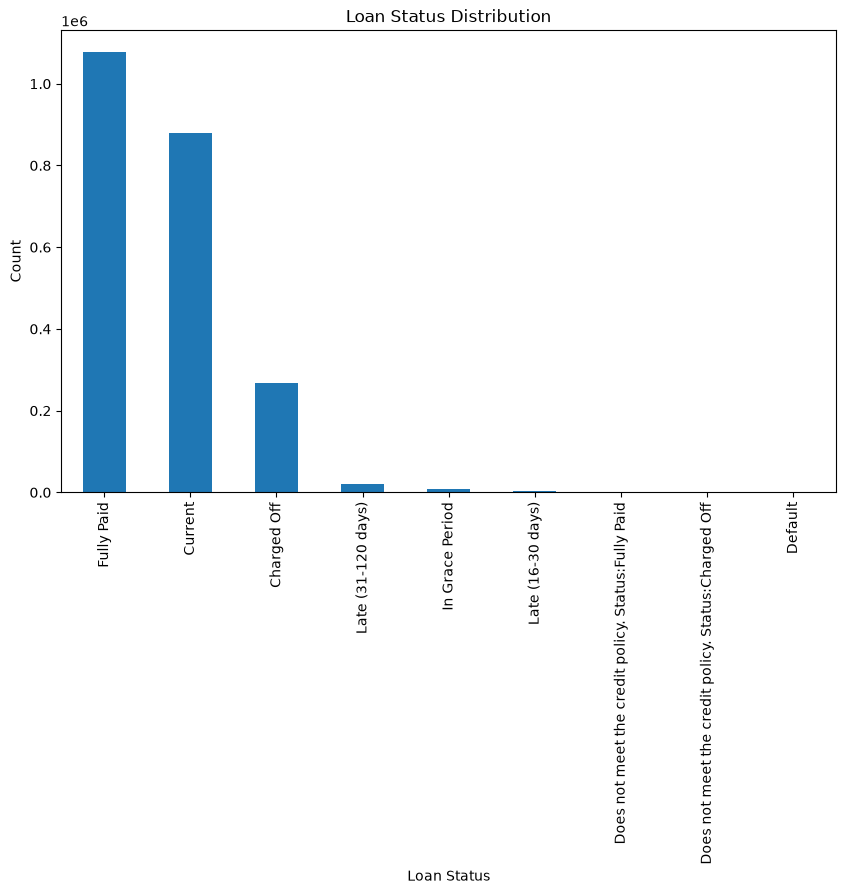

In [11]:
plt.figure(figsize=(10,6))

df["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [12]:
risk_df = df[
    df["loan_status"].isin(
        ["Fully Paid", "Charged Off"]
    )
].copy()

In [13]:
risk_df["loan_status"].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

In [14]:
risk_df["target"] = np.where(
    risk_df["loan_status"] == "Charged Off",
    1,
    0
)

risk_df["target"].value_counts()

target
0    1076751
1     268559
Name: count, dtype: int64

Binary Target Construction

For the initial credit risk analysis, a filtered dataset was created using only Fully Paid and Charged Off loans.

Loans with statuses such as Current, Late and In Grace Period were excluded because their final repayment outcome is not yet fully known. Including such records may introduce uncertainty into the target variable and affect model performance.

The resulting dataset contains 1,345,310 observations, consisting of approximately 80% Fully Paid loans and 20% Charged Off loans. This distribution provides a reasonable balance for supervised credit risk modelling while still reflecting real-world default behaviour.

Risk Driver Analysis - Interest Rate

Interest rate is one of the most important variables in credit risk modelling. Financial institutions generally assign higher interest rates to borrowers who are perceived to have a higher probability of default.

The objective of this analysis is to evaluate whether loans that were eventually charged off were associated with higher interest rates compared to loans that were fully repaid.

In [15]:
risk_df.groupby("target")["int_rate"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1076751.0,12.623288,4.527227,5.31,9.17,12.23,15.31,30.99
1,268559.0,15.710714,4.910387,5.31,12.29,15.05,18.55,30.99


<Figure size 1000x600 with 0 Axes>

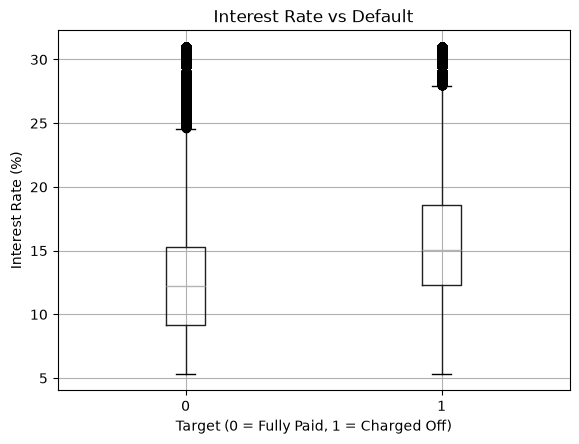

In [16]:
plt.figure(figsize=(10,6))

risk_df.boxplot(
    column="int_rate",
    by="target"
)

plt.title("Interest Rate vs Default")
plt.suptitle("")
plt.xlabel("Target (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("Interest Rate (%)")

plt.show()

Observation

A noticeable difference is observed between the interest rates of fully paid and charged off loans.

The average interest rate for fully paid loans is approximately 12.62%, whereas charged off loans have an average interest rate of approximately 15.71%. Similarly, the median interest rate is higher for defaulted loans.

The boxplot also shows that the distribution of interest rates for charged off loans is shifted towards higher values compared to fully paid loans.

This suggests that borrowers who eventually defaulted were generally assigned higher interest rates at the time of loan approval, indicating that interest rate may serve as a useful proxy for underlying borrower risk.

In [17]:
risk_df.groupby("target")["dti"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1076448.0,17.811629,10.935927,-1.0,11.43,17.11,23.44,999.0
1,268488.0,20.171196,11.831747,0.0,13.55,19.76,26.31,999.0


<Figure size 1000x600 with 0 Axes>

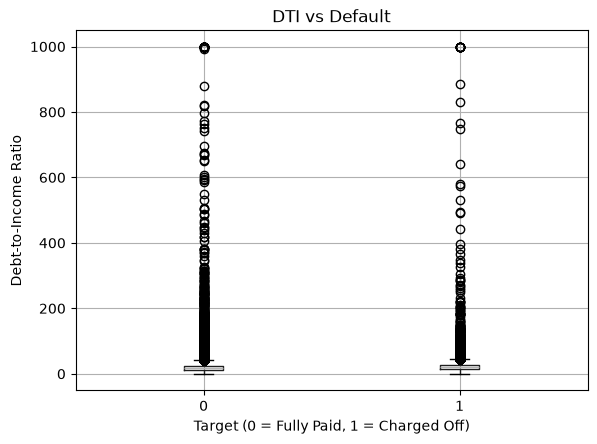

In [18]:
plt.figure(figsize=(10,6))

risk_df.boxplot(
    column="dti",
    by="target"
)

plt.title("DTI vs Default")
plt.suptitle("")
plt.xlabel("Target (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

Data Quality Observation

The DTI feature contains extreme values such as -1 and 999, which are not realistic debt-to-income ratios. These observations may represent placeholder values, data entry issues, or special business codes.

Further investigation and treatment of these outliers will be required during the preprocessing stage before model development.

Observation

Borrowers who eventually defaulted exhibit higher debt-to-income ratios compared to borrowers who fully repaid their loans.

The average DTI for charged off loans is approximately 20.17 compared to 17.81 for fully paid loans. A similar pattern is observed in the median and upper quartile values.

This suggests that borrowers with higher existing debt obligations may face greater financial stress and therefore have an increased probability of default.

In [19]:
risk_df.groupby("target")["fico_range_low"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1076751.0,698.263902,32.833650,625.0,675.0,690.0,715.0,845.0
1,268559.0,687.850119,25.948579,660.0,670.0,680.0,700.0,845.0


<Figure size 1000x600 with 0 Axes>

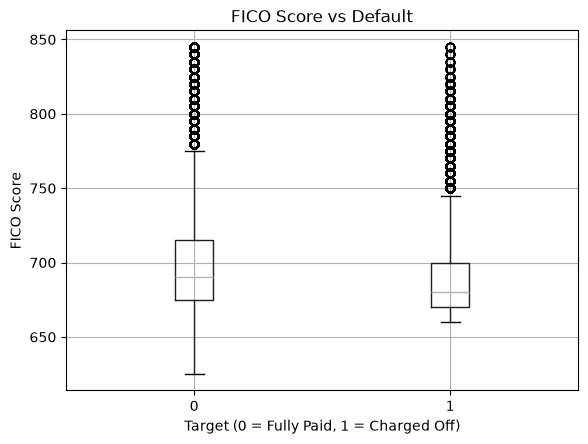

In [20]:
plt.figure(figsize=(10,6))

risk_df.boxplot(
    column="fico_range_low",
    by="target"
)

plt.title("FICO Score vs Default")
plt.suptitle("")
plt.xlabel("Target (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("FICO Score")

plt.show()

Observation

A clear relationship is observed between FICO score and loan performance.

Borrowers who fully repaid their loans have an average FICO score of approximately 698, whereas borrowers who were charged off have an average FICO score of approximately 688. A similar difference is observed in the median values.

The boxplot indicates that the distribution of FICO scores for charged off loans is shifted towards lower values compared to fully paid loans.

This finding is consistent with credit risk theory, where borrowers with stronger credit histories and higher credit scores generally exhibit lower probabilities of default.

In [21]:
risk_df[[
    "int_rate",
    "dti",
    "fico_range_low",
    "loan_amnt",
    "annual_inc",
    "revol_util",
    "delinq_2yrs",
    "target"
]].corr(numeric_only=True)

,int_rate,dti,fico_range_low,loan_amnt,annual_inc,revol_util,delinq_2yrs,target
int_rate,1.000000,0.146886,-0.405367,0.141673,-0.072245,0.243152,0.048311,0.258792
dti,0.146886,1.000000,-0.061927,0.032057,-0.140488,0.140801,-0.007712,0.084510
fico_range_low,-0.405367,-0.061927,1.000000,0.100984,0.070992,-0.459971,-0.174534,-0.130683
loan_amnt,0.141673,0.032057,0.100984,1.000000,0.311794,0.108478,-0.003008,0.065604
annual_inc,-0.072245,-0.140488,0.070992,0.311794,1.000000,0.035254,0.040596,-0.041759
revol_util,0.243152,0.140801,-0.459971,0.108478,0.035254,1.000000,-0.011119,0.060048
delinq_2yrs,0.048311,-0.007712,-0.174534,-0.003008,0.040596,-0.011119,1.000000,0.019381
target,0.258792,0.084510,-0.130683,0.065604,-0.041759,0.060048,0.019381,1.000000


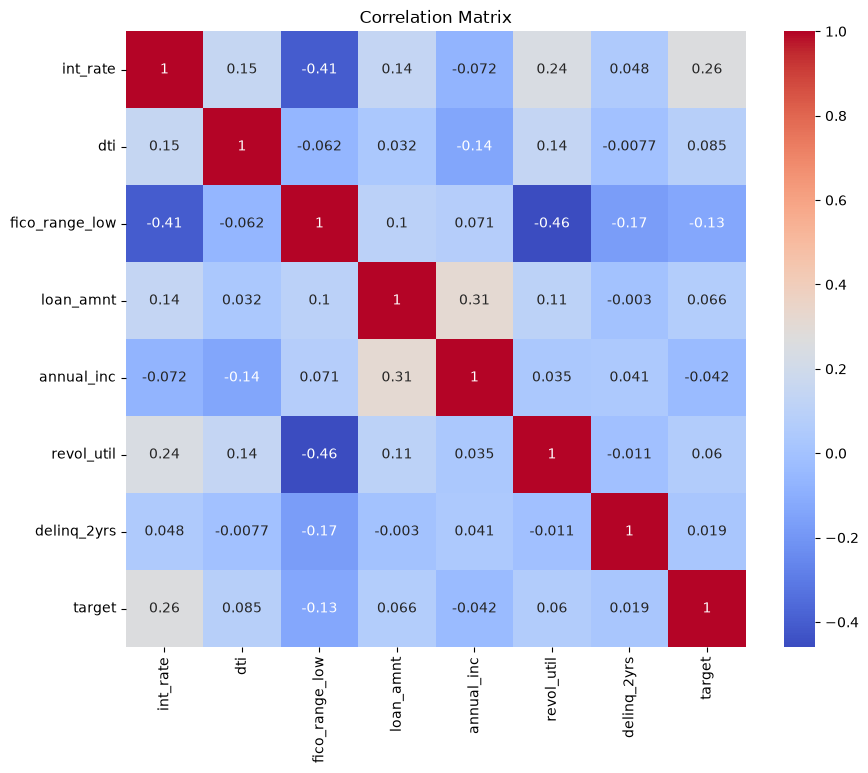

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    risk_df[[
        "int_rate",
        "dti",
        "fico_range_low",
        "loan_amnt",
        "annual_inc",
        "revol_util",
        "delinq_2yrs",
        "target"
    ]].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Correlation Analysis

A correlation analysis was performed to understand the relationships between key borrower attributes and loan default behaviour.

Key Findings

Interest Rate shows the strongest positive correlation with default (0.259), indicating that borrowers assigned higher interest rates were more likely to be charged off.
FICO Score exhibits a negative correlation with default (-0.131), suggesting that borrowers with stronger credit histories generally demonstrate lower default risk.
Debt-to-Income Ratio (DTI) shows a positive relationship with default (0.085), indicating that borrowers with higher existing debt obligations may face greater repayment stress.
Annual Income displays a weak negative correlation with default (-0.042), implying that income alone may not be a strong predictor of repayment performance.
 A notable negative correlation is observed between FICO Score and Interest Rate (-0.41), indicating that borrowers with stronger credit profiles generally receive more favourable loan pricing.

Overall, the analysis suggests that Interest Rate, FICO Score, and DTI are among the most relevant variables for further credit risk modelling.

In [23]:
risk_df.groupby("target")["annual_inc"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1076751.0,77705.945505,70934.960307,0.0,47000.0,65000.0,93000.0,10999200.0
1,268559.0,70400.743283,65394.909259,0.0,43000.0,60000.0,85000.0,9500000.0


<Figure size 1000x600 with 0 Axes>

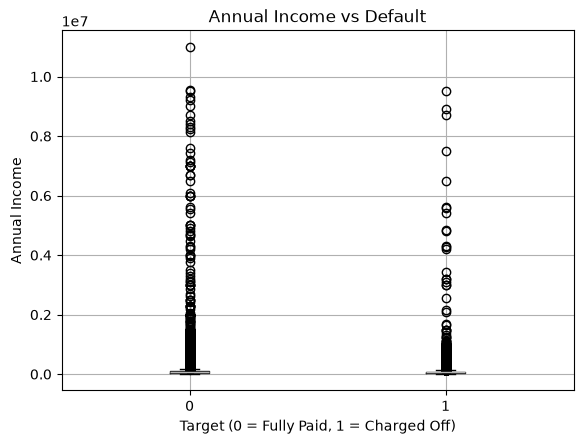

In [24]:
plt.figure(figsize=(10,6))

risk_df.boxplot(
    column="annual_inc",
    by="target"
)

plt.title("Annual Income vs Default")
plt.suptitle("")
plt.xlabel("Target (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("Annual Income")

plt.show()

In [25]:
risk_df.groupby("target")["revol_util"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,1076074.0,51.074671,24.626821,0.0,32.5,51.3,70.1,892.3
1,268379.0,54.758433,23.865982,0.0,37.4,55.5,73.1,366.6


<Figure size 1000x600 with 0 Axes>

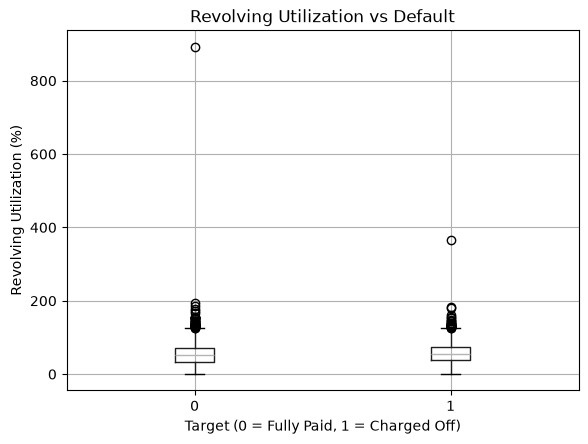

In [26]:
plt.figure(figsize=(10,6))

risk_df.boxplot(
    column="revol_util",
    by="target"
)

plt.title("Revolving Utilization vs Default")
plt.suptitle("")
plt.xlabel("Target (0 = Fully Paid, 1 = Charged Off)")
plt.ylabel("Revolving Utilization (%)")

plt.show()

In [27]:
pd.crosstab(
    risk_df["grade"],
    risk_df["target"],
    normalize="index"
) * 100

target,0,1
grade,,
A,93.959335,6.040665
B,86.614843,13.385157
C,77.560351,22.439649
D,69.617771,30.382229
E,61.521623,38.478377
F,54.797554,45.202446
G,50.065703,49.934297


In [28]:
pd.crosstab(
    risk_df["purpose"],
    risk_df["target"],
    normalize="index"
).sort_values(1, ascending=False) * 100

target,0,1
purpose,,
small_business,70.290607,29.709393
renewable_energy,76.312969,23.687031
moving,76.645570,23.354430
house,78.119399,21.880601
medical,78.224251,21.775749
debt_consolidation,78.853062,21.146938
other,78.959872,21.040128
vacation,80.827358,19.172642
major_purchase,81.400170,18.599830


Week 1 Summary

The Lending Club Accepted Loans dataset was successfully ingested and analysed as part of the initial project phase. The dataset contains approximately 2.26 million records and 151 features, satisfying the project requirements. Data quality checks identified no duplicate records, however several hardship and settlement related features contained extremely high missing percentages and were flagged as potential target leakage variables. A binary target variable was created using Fully Paid and Charged Off loans, resulting in a modelling dataset of approximately 1.35 million observations.

Exploratory Data Analysis identified several important risk drivers. Interest Rate showed the strongest positive relationship with default behaviour, while FICO Score demonstrated a negative relationship, indicating that borrowers with stronger credit histories generally exhibit lower default risk. Debt-to-Income Ratio (DTI), Revolving Utilization, and Annual Income also showed meaningful relationships with loan outcomes. Grade analysis revealed a clear increase in default rates from Grade A to Grade G, validating the effectiveness of Lending Club's internal risk grading system. Purpose analysis showed that Small Business loans exhibited the highest default rates among the analysed loan categories.

Overall, the initial analysis suggests that Interest Rate, Grade/Sub-grade, FICO Score, DTI, Revolving Utilization, and Annual Income are strong candidate features for credit risk modelling. The next phase of the project will focus on feature selection, handling missing values and outliers, removing leakage variables, building preprocessing pipelines, and developing baseline machine learning models for default prediction.